In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from statsforecast import StatsForecast
from statsforecast.models import (Naive, WindowAverage, RandomWalkWithDrift,
                                   AutoARIMA, AutoETS, SeasonalNaive, SeasonalWindowAverage)
from utilsforecast.evaluation import evaluate
import utilsforecast.losses as ufl

c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


meta_encoded: meta numeric
weekly_sales: meta + sales, all stores
X_df : merged weekly future data, all stores
df: sales - open , first 100 stores
df2: reduced future data


In [88]:
# Loading data
sales = pd.read_csv("sales_data.csv", parse_dates=["date"]).rename(columns={'date':'ds','store_id':'unique_id','sales':'y'})
future = pd.read_csv("future_values.csv", parse_dates=["date"]).rename(columns={'date':'ds','store_id':'unique_id'})
meta = pd.read_csv("metadata.csv").rename(columns={'store_id':'unique_id'})

C:\Users\pc\AppData\Local\Temp\ipykernel_16908\2847012046.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  sales = pd.read_csv("sales_data.csv", parse_dates=["date"]).rename(columns={'date':'ds','store_id':'unique_id','sales':'y'})


C:\Users\pc\AppData\Local\Temp\ipykernel_16908\3698847728.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=weekly_data, x='ds', y='customers', estimator='sum', ci=None)


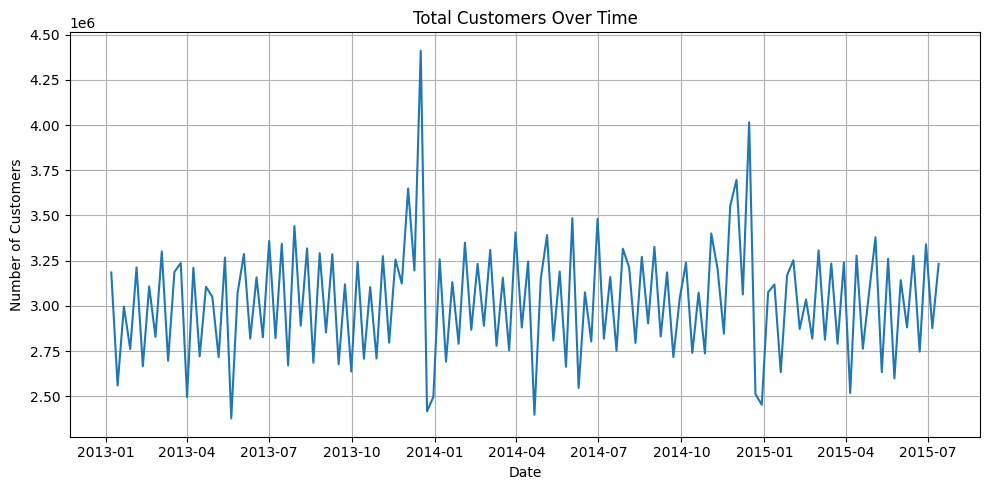

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by date just in case
weekly_data = sales.sort_values('ds')

# Plot all stores combined (total customers per week)
plt.figure(figsize=(10, 5))
sns.lineplot(data=weekly_data, x='ds', y='customers', estimator='sum', ci=None)

plt.title('Total Customers Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Customers')
plt.grid(True)
plt.tight_layout()
plt.show()


import matplotlib.pyplot as plt
import seaborn as sns

# Basic scatter plot: Customers vs Sales
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sales, x='customers', y='y', alpha=0.6)

plt.title('Sales vs Customers')
plt.xlabel('Customers')
plt.ylabel('Sales')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
#Range of future values 
# Grouping data by each time series
grouped = future.groupby('unique_id')

print("\nDate range per unique_id:")
date_range = future.groupby('unique_id')['ds'].agg(['min', 'max', 'count'])
print(date_range)

# Creating a summary dataframe for visualizing data completeness
summary = grouped.agg(
    count_observed=('ds', 'count'),
    start_date=('ds', 'min'),
    end_date=('ds', 'max')
).reset_index()

summary['expected_count'] = (
    (summary['end_date'].dt.to_period('M') - summary['start_date'].dt.to_period('M')).apply(lambda x: x.n) + 1
)

# Identifying which time series are irregular
summary['is_irregular'] = summary['count_observed'] < summary['expected_count']

filtered = summary[summary['is_irregular'] == True]
display(filtered)


Date range per unique_id:
                 min        max  count
unique_id                             
store_1   2015-07-20 2015-09-14     60
store_10  2015-07-20 2015-09-14     60
store_100 2015-07-20 2015-09-14     60
store_101 2015-07-20 2015-09-14     60
store_102 2015-07-20 2015-09-14     60
...              ...        ...    ...
store_95  2015-07-20 2015-09-14     60
store_96  2015-07-20 2015-09-14     60
store_97  2015-07-20 2015-09-14     60
store_98  2015-07-20 2015-09-14     60
store_99  2015-07-20 2015-09-14     60

[676 rows x 3 columns]


,unique_id,count_observed,start_date,end_date,expected_count,is_irregular


In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assuming `sales_data` is already loaded and has the correct columns
data = pd.get_dummies(sales, columns=['state_holiday'], prefix='state_holiday', drop_first=False)

# Define lags in days (assuming daily data)
lags = [0, 7, 14, 28, 56]
lag_labels = ['0w', '1w', '2w', '4w', '8w']

# Get all state holiday dummy columns
state_holiday_dummies = [col for col in data.columns if col.startswith('state_holiday_')]

# Define exogenous variables to analyze
base_vars = ['customers', 'open', 'promo', 'school_holiday']
exog_vars = base_vars + state_holiday_dummies

# Initialize correlation matrix
correlation_matrix = pd.DataFrame(index=exog_vars, columns=lag_labels)

# Compute correlation for each lag
for lag, label in zip(lags, lag_labels):
    lagged_y = data['y'].shift(-lag)  # align exog with future y
    for var in exog_vars:
        if var in data.columns:
            corr = data[var].corr(lagged_y)
            correlation_matrix.loc[var, label] = corr

# Plot heatmap
plt.figure(figsize=(10, 6))
plt.title("Correlation between 'y' and Exogenous Variables at Different Lags")
im = plt.imshow(correlation_matrix.astype(float), cmap="coolwarm", aspect='auto', vmin=-1, vmax=1)
plt.colorbar(im, label='Correlation')

# Axis labels
plt.xticks(ticks=np.arange(len(lag_labels)), labels=lag_labels)
plt.yticks(ticks=np.arange(len(exog_vars)), labels=exog_vars)

# Add correlation values
for i in range(len(exog_vars)):
    for j in range(len(lag_labels)):
        val = correlation_matrix.iloc[i, j]
        if pd.notnull(val):
            plt.text(j, i, f"{float(val):.2f}", ha='center', va='center', color='black')

plt.xlabel("Lag (weeks)")
plt.ylabel("Exogenous Variables")
plt.tight_layout()
plt.show()


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [3]:
# Dummy encoding metadata
meta_encoded = pd.get_dummies(meta, columns=['store_type', 'assortment'], drop_first=True)
for col in meta_encoded.columns:
    if meta_encoded[col].dtype == bool:
        meta_encoded[col] = meta_encoded[col].astype(int)

meta_encoded.head()

,unique_id,competition_distance,store_type_b,store_type_c,store_type_d,assortment_b,assortment_c
0,store_1,1270.0,0,1,0,0,0
1,store_2,14130.0,0,0,0,0,0
2,store_3,24000.0,0,0,0,0,1
3,store_4,7520.0,0,0,0,0,0
4,store_5,2030.0,0,0,0,0,1


In [4]:
# Dummy encoding sales data
sales['state_holiday'] = sales['state_holiday'].astype(str)
sales = pd.get_dummies(sales, columns=['state_holiday'], prefix='holiday', drop_first=True)
for col in sales.columns:
    if col.startswith('holiday_') and sales[col].dtype == bool:
        sales[col] = sales[col].astype(int)

# Merging with metadata and aggregating to weekly
sales = sales.merge(meta_encoded, on='unique_id', how='left')
sales['ds'] = sales['ds'].dt.to_period('W').apply(lambda r: r.start_time) 

agg_sales = {
    'y': 'sum',
    'customers': 'sum',
    'open': 'mean',
    'promo': 'mean',
    'school_holiday': 'mean',
    'competition_distance': 'first',
    'holiday_a': 'sum',
    'holiday_b': 'sum',
    'holiday_c': 'sum',
    **{col: 'first' for col in meta_encoded.columns if col != 'unique_id'}
}

weekly_sales = sales.groupby(['unique_id', 'ds']).agg(agg_sales).reset_index()
weekly_sales['competition_distance'].fillna(weekly_sales['competition_distance'].median(), inplace=True)
weekly_sales.head()

C:\Users\pc\AppData\Local\Temp\ipykernel_16908\1696443983.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  weekly_sales['competition_distance'].fillna(weekly_sales['competition_distance'].median(), inplace=True)


,unique_id,ds,y,customers,open,promo,school_holiday,competition_distance,holiday_a,holiday_b,holiday_c,store_type_b,store_type_c,store_type_d,assortment_b,assortment_c
0,store_1,2013-01-07,32952,3918,0.857143,0.714286,0.714286,1270.0,0,0,0,0,1,0,0,0
1,store_1,2013-01-14,25978,3417,0.857143,0.000000,0.000000,1270.0,0,0,0,0,1,0,0,0
2,store_1,2013-01-21,33071,3862,0.857143,0.714286,0.000000,1270.0,0,0,0,0,1,0,0,0
3,store_1,2013-01-28,28693,3561,0.857143,0.000000,0.000000,1270.0,0,0,0,0,1,0,0,0
4,store_1,2013-02-04,35771,4094,0.857143,0.714286,0.000000,1270.0,0,0,0,0,1,0,0,0


In [5]:
# --- Prepare df for StatsForecast ---
#df = weekly_sales.rename(columns={'store_id': 'unique_id', 'week': 'ds', 'sales': 'y'})

#Dummy encoding, merging and aggregating of future data

future['state_holiday'] = future['state_holiday'].astype(str)
future = pd.get_dummies(future, columns=['state_holiday'], prefix='holiday', drop_first=True)
# Ensure all required holiday columns exist
for col in ['holiday_a', 'holiday_b', 'holiday_c']:
    if f'holiday_{col[-1]}' not in future.columns:
        future[f'holiday_{col[-1]}'] = 0

#for col in future.columns:
 #   if col.startswith('holiday_') and future[col].dtype == bool:
  #      future[col] = future[col].astype(int)

# One-hot encode state_holiday
#future = pd.get_dummies(future, columns=['state_holiday'], prefix='holiday', drop_first=False)

future = future.merge(meta_encoded, on='unique_id', how='left')
future['ds'] = future['ds'].dt.to_period('W').apply(lambda r: r.start_time)

agg_future = {
    'promo': 'mean',
    'school_holiday': 'mean',
    'customers': 'mean',
    'competition_distance': 'first',
    'holiday_a': 'sum',
    'holiday_b': 'sum',
    'holiday_c': 'sum',
    **{col: 'first' for col in meta_encoded.columns if col != 'unique_id'}
}

#weekly_future = future.groupby(['unique_id', 'week']).agg(agg_future).reset_index()
#X_df = weekly_future.rename(columns={'store_id': 'unique_id', 'week': 'ds'})
X_df = future.groupby(['unique_id', 'ds']).agg(agg_future).reset_index()
X_df.head()

,unique_id,ds,promo,school_holiday,customers,competition_distance,holiday_a,holiday_b,holiday_c,store_type_b,store_type_c,store_type_d,assortment_b,assortment_c
0,store_1,2015-07-20,0.000000,0.0,NaN,1270.0,0,0,0,0,1,0,0,0
1,store_1,2015-07-27,0.714286,1.0,NaN,1270.0,0,0,0,0,1,0,0,0
2,store_1,2015-08-03,0.714286,1.0,NaN,1270.0,0,0,0,0,1,0,0,0
3,store_1,2015-08-10,0.000000,1.0,NaN,1270.0,0,0,0,0,1,0,0,0
4,store_1,2015-08-17,0.714286,1.0,NaN,1270.0,0,0,0,0,1,0,0,0


In [6]:
# Defining models
models = [
    Naive(), 
    WindowAverage(window_size=12), 
    RandomWalkWithDrift(),
    AutoARIMA(season_length=52),
    AutoETS(season_length=52),
    SeasonalNaive(season_length=52),
    SeasonalWindowAverage(season_length=52, window_size=12)
]

sf = StatsForecast(models=models, freq='W')

In [7]:
# Transforming sales data to fix xreg is rank deficient error
df = weekly_sales.copy().drop(columns={'open'})

# Filter only store_1 to store_99 (inclusive)
first_100_stores = [f'store_{i}' for i in range(1, 100)]  # store_1 to store_99
df = df[df['unique_id'].isin(first_100_stores)]
df.to_csv("first_100.csv", index=False)

df.head()

,unique_id,ds,y,customers,promo,school_holiday,competition_distance,holiday_a,holiday_b,holiday_c,store_type_b,store_type_c,store_type_d,assortment_b,assortment_c
0,store_1,2013-01-07,32952,3918,0.714286,0.714286,1270.0,0,0,0,0,1,0,0,0
1,store_1,2013-01-14,25978,3417,0.000000,0.000000,1270.0,0,0,0,0,1,0,0,0
2,store_1,2013-01-21,33071,3862,0.714286,0.000000,1270.0,0,0,0,0,1,0,0,0
3,store_1,2013-01-28,28693,3561,0.000000,0.000000,1270.0,0,0,0,0,1,0,0,0
4,store_1,2013-02-04,35771,4094,0.714286,0.000000,1270.0,0,0,0,0,1,0,0,0


In [8]:
# Transforming future data to fix dimension error
df2 = X_df.copy()  #zırt pırt baştan yüklememek için değişimleri kopyasında yapıyorum 
first_99_stores = df['unique_id'].unique()[:99]
df2 = df2[df2['unique_id'].isin(first_99_stores)]

last_date = pd.to_datetime(df['ds'].max())
future_weeks = pd.date_range(start=last_date + pd.Timedelta(days=7), periods=8, freq='W-MON')

df2['ds'] = pd.to_datetime(df2['ds'])  # ensure type match
df2 = df2[df2['ds'].isin(future_weeks)]

# checking shape
print(f'Final X_df shape: {df2.shape}')
# Should be exactly (99 × 8, 14) → (792, 14)


Final X_df shape: (792, 14)


Cross v.  from exr. 7 

In [ ]:
# Create cross-validation and forecast into the future
models = [Naive(), WindowAverage(window_size=8), RandomWalkWithDrift(), AutoARIMA(season_length=52), AutoETS(season_length=52), SeasonalNaive(season_length=52), SeasonalWindowAverage(season_length=52, window_size=8)]
sf = StatsForecast(models=models, freq='W')
cv_df = sf.cross_validation(df=df, step_size=13, n_windows=9, h=8) #step size = quarter 


c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages\statsforecast\ets.py:657: RuntimeWarning: divide by zero encountered in scalar divide
  sigma2 = np.sum(e**2) / (ny - np_ - 1)
c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages\statsforecast\ets.py:657: RuntimeWarning: divide by zero encountered in scalar divide
  sigma2 = np.sum(e**2) / (ny - np_ - 1)
c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages\statsforecast\ets.py:657: RuntimeWarning: divide by zero encountered in scalar divide
  sigma2 = np.sum(e**2) / (ny - np_ - 1)
c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages\statsforecast\ets.py:657: RuntimeWarning: divide by zero encountered in scalar divide
  sigma2 = np.sum(e**2) / (ny - np_ - 1)
c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages\statsforecast\ets.py:657: RuntimeWarning: divide by zero encountered in scalar divide
  sigma2 = np.sum(e**2) / (ny - np_ - 1)
c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages

In [ ]:
fc_df = sf.forecast(df=df, h=8, X_df=df2)  

In [44]:
# Calculate error metrics for cross-validation
metrics = evaluate(cv_df.drop(columns={'cutoff'}), metrics=[ufl.mse, ufl.mape])

In [59]:
# Choose MSE for accuracy evaluation and prepare metrics data 
metric_for_selection = 'mse'
metrics = metrics[metrics.metric == metric_for_selection].drop('metric', axis=1)
metrics = metrics.melt(id_vars='unique_id', var_name='method', value_name='metric')
metrics = metrics.sort_values(['unique_id', 'metric'])

In [67]:
metrics
store_99_metrics = metrics[metrics['unique_id'] == 'store_1']
store_99_metrics

,unique_id,method,metric
297,store_1,AutoARIMA,1.308087e+06
693,store_1,Best-Fit,1.308087e+06
1089,store_1,InverseMSE-Best3,1.491451e+06
990,store_1,InverseMSE,2.117913e+06
891,store_1,Equal-Best3,1.065401e+07
99,store_1,WindowAverage,2.760832e+07
495,store_1,SeasonalNaive,2.905032e+07
396,store_1,AutoETS,3.063231e+07
0,store_1,Naive,3.535985e+07
792,store_1,Equal-All,3.750963e+07


In [47]:
# Function for calculating different ensemble types
def compute_ensemble_weights(df):
    df = df.copy()
    n_models = len(df)

    df['Best-Fit'] = 0.0
    df.iloc[0, df.columns.get_loc('Best-Fit')] = 1.0

    df['Equal-All'] = 1.0 / n_models

    df['Equal-Best3'] = 0.0
    top_n = min(3, n_models)
    df.iloc[:top_n, df.columns.get_loc('Equal-Best3')] = 1.0 / top_n

    inverse = 1.0 / df['metric']
    df['InverseMSE'] = inverse / inverse.sum()

    df['InverseMSE-Best3'] = 0.0
    top_n = min(3, n_models)
    inverse = 1.0 / df['metric'][:top_n]
    df.iloc[:top_n, df.columns.get_loc('InverseMSE-Best3')] = inverse / inverse.sum()

    long_weights = df.melt(
        id_vars=['method', 'unique_id'],
        value_vars=['Best-Fit', 'Equal-All', 'Equal-Best3', 'InverseMSE', 'InverseMSE-Best3'],
        var_name='ensemble_type',
        value_name='weight'
    )
    long_weights = long_weights[long_weights['weight'] > 0].reset_index(drop=True)

    return long_weights

In [48]:
# Create weights and multiply them with forecasts
weights_df = metrics.groupby('unique_id', group_keys=False).apply(compute_ensemble_weights)
forecasts_long = cv_df.melt(
    id_vars=['unique_id', 'ds', 'cutoff'],
    var_name='method',
    value_name='fc'
)
ensemble_fc = weights_df.merge(forecasts_long, how='left')
ensemble_fc['weighted_fc'] = ensemble_fc['fc'] * ensemble_fc['weight'] 
ensemble_fc = ensemble_fc.groupby(['unique_id', 'ensemble_type', 'ds', 'cutoff']).agg({'weighted_fc': 'sum'}).reset_index()
ensemble_fc = ensemble_fc.pivot(index=['unique_id', 'ds', 'cutoff'], values='weighted_fc', columns='ensemble_type').reset_index()

C:\Users\pc\AppData\Local\Temp\ipykernel_16908\1406636858.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weights_df = metrics.groupby('unique_id', group_keys=False).apply(compute_ensemble_weights)


In [ ]:
ensemble_fc

ensemble_type,unique_id,ds,Best-Fit,Equal-All,Equal-Best3,InverseMSE,InverseMSE-Best3
0,store_1,2015-07-19,0.0,18936.884727,16496.333333,4438.800518,2094.935561
1,store_1,2015-07-26,0.0,19940.510681,18849.333333,4702.117400,2385.902702
2,store_1,2015-08-02,0.0,19681.136636,18255.333333,4634.558090,2312.449884
3,store_1,2015-08-09,0.0,18821.048304,16259.666667,4409.625814,2065.669848
4,store_1,2015-08-16,0.0,19352.817115,17511.666667,4549.327260,2220.489593
...,...,...,...,...,...,...,...
787,store_99,2015-08-09,0.0,34575.144532,32562.159125,5747.419624,3175.825875
788,store_99,2015-08-16,0.0,36971.806473,32562.159125,6204.151229,3175.825875
789,store_99,2015-08-23,0.0,34779.896986,32562.159125,5788.032360,3175.825875
790,store_99,2015-08-30,0.0,37473.987498,32562.159125,6301.341633,3175.825875


In [49]:
# Evaluate ensmeble and old models
full_fc = cv_df.merge(ensemble_fc)
metrics = evaluate(full_fc.drop(columns={'cutoff'}), metrics=[ufl.mse, ufl.mape])


In [50]:
full_fc.to_csv("full_fc2.csv", index=False)
metrics.to_csv("metrics2.csv", index=False)

In [51]:
# Create ensmeble forecasts into the future using established weights, finally plot it
forecasts_long = fc_df.melt(
    id_vars=['unique_id', 'ds'],
    var_name='method',
    value_name='fc'
)
ensemble_fc = weights_df.merge(forecasts_long, how='left')
ensemble_fc['weighted_fc'] = ensemble_fc['fc'] * ensemble_fc['weight'] 
ensemble_fc = ensemble_fc.groupby(['unique_id', 'ensemble_type', 'ds']).agg({'weighted_fc': 'sum'}).reset_index()
ensemble_fc = ensemble_fc.pivot(index=['unique_id', 'ds'], values='weighted_fc', columns='ensemble_type').reset_index()



In [52]:
ensemble_fc.to_csv("ensemble_fc2.csv", index=False)

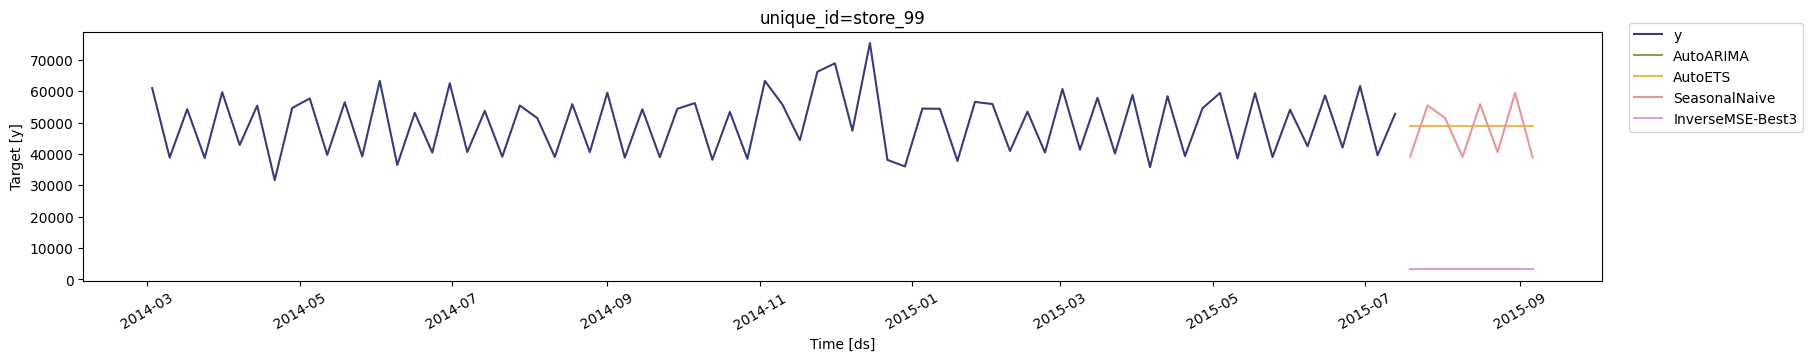

In [62]:
# Example plot
StatsForecast.plot(df=weekly_sales, forecasts_df=ensemble_fc.merge(ensemble_fc.merge(fc_df)), unique_ids=['store_99'],
                   models=['AutoARIMA', 'AutoETS', 'SeasonalNaive', 'InverseMSE-Best3'], max_insample_length=72)


------ exr 7 cv end ----- 

there are dimensional differences between sales data and future data which raises an error. correcting for the error 

In [20]:
df2 = X_df.copy()  #zırt pırt baştan yüklememek için değişimleri kopyasında yapıyorum 
first_99_stores = df['unique_id'].unique()[:99]
df2 = df2[df2['unique_id'].isin(first_99_stores)]

last_date = pd.to_datetime(df['ds'].max())
future_weeks = pd.date_range(start=last_date + pd.Timedelta(days=7), periods=8, freq='W-MON')

df2['ds'] = pd.to_datetime(df2['ds'])  # ensure type match
df2 = df2[df2['ds'].isin(future_weeks)]

# checking shape
print(f'Final X_df shape: {df2.shape}')
# Should be exactly (99 × 8, 14) → (792, 14)



Final X_df shape: (792, 14)


In [ ]:
# --- Final Forecast ---
fc_df = sf.forecast(df=df, h=8, X_df=df2)
fc_df.to_csv("final_forecast_results.csv", index=False)

print("Forecasting pipeline complete. Forecasts saved.")

Lecture 8 Random Forest 

In [9]:
import operator

import optuna
import pandas as pd

from mlforecast import MLForecast
from mlforecast.auto import AutoModel, AutoMLForecast
from mlforecast.lag_transforms import Combine, ExpandingMean, RollingMean
from mlforecast.target_transforms import Differences, LocalBoxCox
from statsforecast import StatsForecast
from sklearn.ensemble import RandomForestRegressor
from utilsforecast.evaluation import evaluate
import utilsforecast.losses as ufl

Random forest test 1 start 

In [ ]:
data = weekly_sales[weekly_sales['unique_id'].isin(first_100_stores)]
static_ft = ['store_type_b', 'store_type_c', 'store_type_d', 'assortment_b', 'assortment_c']

# Specify random forest
# These specifications are too low / supoptimal, just an example and meant to imporve speed of this script
models = [RandomForestRegressor(n_estimators=800, max_features='sqrt', min_samples_leaf=10)]
fcst = MLForecast(
    models=models,
    freq='W',
    lags=[1, 2, 4, 8],
    date_features=['week'],
    target_transforms=[Differences([1])],
    lag_transforms={
        1: [RollingMean(window_size=2)]
    }
)

# Run the forecast
print(fcst.preprocess(data, static_features= static_ft))  # Just to take a look at the data, not necessary
fcst.fit(data, static_features= static_ft)
fc_df = fcst.predict(h=8)
StatsForecast.plot(df=data, forecasts_df=fc_df, max_insample_length=24*7*10)




      unique_id         ds        y  customers      open     promo  \
9       store_1 2013-03-11  -8837.0       3748  0.857143  0.000000   
10      store_1 2013-03-18   7342.0       4223  0.857143  0.714286   
11      store_1 2013-03-25  -1029.0       3978  0.714286  0.714286   
12      store_1 2013-04-01 -10625.0       3017  0.714286  0.000000   
13      store_1 2013-04-08   6998.0       3627  0.857143  0.714286   
...         ...        ...      ...        ...       ...       ...   
89227  store_99 2015-06-15  16214.0       5517  0.857143  0.714286   
89228  store_99 2015-06-22 -16630.0       4475  0.857143  0.000000   
89229  store_99 2015-06-29  19624.0       5508  0.857143  0.714286   
89230  store_99 2015-07-06 -22076.0       4162  0.857143  0.000000   
89231  store_99 2015-07-13  13222.0       4909  0.857143  0.714286   

       school_holiday  competition_distance  holiday_a  holiday_b  ...  \
9            0.000000                1270.0          0          0  ...   
10         

KeyError: "['customers', 'open', 'promo', 'school_holiday', 'competition_distance', 'holiday_a', 'holiday_b', 'holiday_c'] not in index"

In [ ]:
# Run a cross validation
# These specifications are too low / supoptimal, just an example and meant to imporve speed of this script
cv_df = fcst.cross_validation(data, n_windows=2, h=168)
metrics = [ufl.mse, ufl.mape]
metrics_df = evaluate(df=cv_df.drop(columns={'cutoff'}), metrics=metrics)
metrics_df
print('Cross-Validation finished. Running second half.')

Random forest test 1 end

In [74]:
fcst = MLForecast(
    models=models,
    freq='W',
    lags=[1, 2, 4, 8],
    date_features=['weekofyear'],
    static_features=['store_type_b', 'store_type_c', 'store_type_d', 'assortment_b', 'assortment_c'],
    exogenous_features=['promo', 'school_holiday', 'holiday_a', 'holiday_b', 'holiday_c']
)




TypeError: MLForecast.__init__() got an unexpected keyword argument 'static_features'

## og 
fcst = MLForecast(
    models=models,
    freq='h',
    lags=[1, 2, 4, 8],   #weekly lags 
    date_features=['dayofweek', 'hour'],
    target_transforms=[Differences([1])],
    lag_transforms={
        1: [RollingMean(window_size=168)]
    }
)

In [78]:
## og 
models = [RandomForestRegressor(n_estimators=300, max_features='sqrt', min_samples_leaf=3)] 
fcst = MLForecast(
    models=models,
    freq='W',
    lags=[1, 2, 4, 8],   #weekly lags 
    date_features=['week'],
    target_transforms=[Differences([1])],
    lag_transforms={
        1: [RollingMean(window_size=2)]
    }
)

In [79]:
fcst.fit(df, static_features=[])
fc_df = fcst.predict(h=8)

KeyError: "['customers', 'promo', 'school_holiday', 'competition_distance', 'holiday_a', 'holiday_b', 'holiday_c', 'store_type_b', 'store_type_c', 'store_type_d', 'assortment_b', 'assortment_c'] not in index"

In [28]:
# 1. Drop static columns from df2,, fixing error for fcst.predict,, gives error bc of static features
static_cols = ['store_type_b', 'store_type_c', 'store_type_d', 'assortment_b', 'assortment_c']
dynamic_df = df2.drop(columns=static_cols, errors='ignore')

# 2. Create template with full horizon,, fixing error in prediction, not enough future variables for 8 week forecast 
future_template = fcst.make_future_dataframe(h=8)

# 3. Merge exogenous values onto it
df3 = future_template.merge(dynamic_df, on=['unique_id', 'ds'], how='left')

# 4. Forecast
fc_df = fcst.predict(h=8, X_df=df3)
fc_df.to_csv("rf_forecast_results.csv", index=False)


c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages\mlforecast\core.py:625: UserWarning: Found null values in promo, school_holiday, customers, competition_distance, holiday_a, holiday_b, holiday_c.
  warnings.warn(f'Found null values in {", ".join(cols_with_nulls)}.')
c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages\mlforecast\core.py:625: UserWarning: Found null values in promo, school_holiday, customers, competition_distance, holiday_a, holiday_b, holiday_c.
  warnings.warn(f'Found null values in {", ".join(cols_with_nulls)}.')
c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages\mlforecast\core.py:625: UserWarning: Found null values in promo, school_holiday, customers, competition_distance, holiday_a, holiday_b, holiday_c.
  warnings.warn(f'Found null values in {", ".join(cols_with_nulls)}.')
c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages\mlforecast\core.py:625: UserWarning: Found null values in promo, school_holiday, customers, competitio

# --- Predict future 8 weeks ---
fcst.fit(
    df,
    static_features=[
        'store_type_b', 'store_type_c', 'store_type_d',
        'assortment_b', 'assortment_c'
    ]
)

static_cols = ['store_type_b', 'store_type_c', 'store_type_d', 'assortment_b', 'assortment_c']
dynamic_df = df2.drop(columns=static_cols, errors='ignore') 

fc_df = fcst.predict(h=8, X_df=dynamic_df)
fc_df.to_csv("rf_forecast_results.csv", index=False)

# --- Predict future 8 weeks ---
# Run the forecast
print(fcst.preprocess(data))  # Just to take a look at the data, not necessary
fcst.fit(data)
fc_df = fcst.predict(h=8)
StatsForecast.plot(df=data, forecasts_df=fc_df, max_insample_length=24*7*10)

# Run a cross validation
# These specifications are too low / supoptimal, just an example and meant to imporve speed of this script
cv_df = fcst.cross_validation(df, n_windows=2, h=8)
metrics = [ufl.mse, ufl.mape]
metrics_df = evaluate(df=cv_df.drop(columns={'cutoff'}), metrics=metrics)
metrics_df
print('Cross-Validation finished. Running second half.')

# Specifying hyperparameter tuning
# These specifications are too low / supoptimal, just an example and meant to imporve speed of this script
def rf_config(trial: optuna.Trial):
    return {
        'n_estimators':  trial.suggest_int('n_estimators', 500, 800, step=100),
        'max_features': trial.suggest_int('max_features', 3, 5),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 8, 12)
    }
def rf_init_config(trial: optuna.Trial):
    return {
        'lags': [1, 2, 4, 8],
        'date_features': ['dayofweek', 'hour', 'month'],
        'target_transforms': [],  
        'lag_transforms': {
            1: [RollingMean(window_size=2),
                Combine(
                    RollingMean(window_size=2),
                    RollingMean(window_size=4),
                    operator.truediv)
                ],
            2: [RollingMean(window_size=2)]
        }
    }
def mse_trial(df, train_df):
   return ufl.mse(df, models=["model"])["model"].mean()
# Performing hyparameter tuning
# These specifications are too low / supoptimal, just an example and meant to imporve speed of this script
rf_tuned = AutoModel(
    model=RandomForestRegressor(),
    config=rf_config,
)
tuned_random_forest = AutoMLForecast(
    models={'rf_tuned': rf_tuned},
    freq='h',
    init_config=rf_init_config
).fit(
    df,
    n_windows=5,
    h=8,
    num_samples=2,  # number of combinations to try, should be considerably higher
    loss=mse_trial
)

# Investigating hyperparameter tuning
study = tuned_random_forest.results_['rf_tuned']
print(study.trials_dataframe().sort_values('value'))
print(study.best_params)

In [68]:
static_feats = [
    'store_type_b', 'store_type_c', 'store_type_d',
    'assortment_b', 'assortment_c'
]

#to include X_df in cross validation
#df_combined = pd.concat([df, df3], axis=0).sort_values(['unique_id', 'ds'])


cv_df = fcst.cross_validation(
    df,
    n_windows=4,
    step_size= 4,
    h=8,
    static_features=static_feats
)
metrics = [ufl.mse, ufl.mape]
metrics_df = evaluate(df=cv_df.drop(columns={'cutoff'}), metrics=metrics)
metrics_df
print('Cross-Validation finished. Running second half.')

# Specifying hyperparameter tuning 
# These specifications are too low / supoptimal, just an example and meant to imporve speed of this script
def rf_config(trial: optuna.Trial):
    return {
        'n_estimators':  trial.suggest_int('n_estimators', 500, 800, step=100),
        'max_features': trial.suggest_int('max_features', 3, 5),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 8, 12)
    }
def rf_init_config(trial: optuna.Trial):
    return {
        'lags': [1, 2, 4, 8],
        'date_features': ['dayofweek', 'hour', 'month'],
        'target_transforms': [],  
        'lag_transforms': {
            1: [RollingMean(window_size=2),
                Combine(
                    RollingMean(window_size=3),
                    RollingMean(window_size=5),
                    operator.truediv)
                ],
            2: [RollingMean(window_size=3)]
        }
    }
def mse_trial(df, train_df):
   return ufl.mse(df, models=["model"])["model"].mean()
# Performing hyparameter tuning
# These specifications are too low / supoptimal, just an example and meant to imporve speed of this script
rf_tuned = AutoModel(
    model=RandomForestRegressor(),
    config=rf_config,
)
tuned_random_forest = AutoMLForecast(
    models={'rf_tuned': rf_tuned},
    freq='h',
    init_config=rf_init_config
).fit(
    df,
    n_windows=5,
    h=8,
    num_samples=2,  # number of combinations to try, should be considerably higher
    loss=mse_trial
)

# Investigating hyperparameter tuning
study = tuned_random_forest.results_['rf_tuned']
print(study.trials_dataframe().sort_values('value'))
print(study.best_params)

ValueError: Found missing inputs in X_df. It should have one row per id and time for the complete forecasting horizon.
You can get the expected structure by running `MLForecast.make_future_dataframe(h)` or get the missing combinatins in your current `X_df` by running `MLForecast.get_missing_future(h, X_df)`.

Feature importance (Exr 9)

In [92]:
# Speciy model
models = [RandomForestRegressor(n_estimators=500, max_features='sqrt', min_samples_leaf=5)]
fcst = MLForecast(
    models=models,
    freq='W',
    lags=[1, 2, 4, 8],
    date_features= ['week'],
    lag_transforms={
        1: [RollingMean(window_size=2),
            Combine(
                RollingMean(window_size=2),
                RollingMean(window_size=4),
                operator.truediv)
            ],
        2: [RollingMean(window_size=2)]
    }
)


In [96]:
from mlforecast import MLForecast
from mlforecast.lag_transforms import Combine, RollingMean
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor

# Permutation Importance
features_data = fcst.preprocess(df , static_features=['store_type_b', 'store_type_c', 'store_type_d', 'assortment_b', 'assortment_c'])
eval_size = 500
train_data = df.iloc[:-eval_size].copy()
eval = features_data.iloc[-eval_size:].copy()
X = eval.drop(['y', 'ds', 'unique_id'], axis=1)
y = eval['y']

fcst.fit(train_data,static_features=['store_type_b', 'store_type_c', 'store_type_d', 'assortment_b', 'assortment_c'], fitted=True)
model_rf = fcst.models_['RandomForestRegressor']
perm_importance = permutation_importance(
    model_rf,
    X,
    y,
    scoring='neg_mean_squared_error',
    n_repeats=10,
    random_state=42
)
print(perm_importance)

c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages\mlforecast\lag_transforms.py:306: RuntimeWarning: invalid value encountered in divide
  return self.operator(self.tfm1.transform(ga), self.tfm2.transform(ga))
c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages\mlforecast\lag_transforms.py:306: RuntimeWarning: invalid value encountered in divide
  return self.operator(self.tfm1.transform(ga), self.tfm2.transform(ga))


{'importances_mean': array([ 1.33290959e+07,  5.99509510e+07,  1.07612516e+06,  3.78007586e+05,
        5.02067960e+05,  1.01219717e+05,  1.94940999e+05,  0.00000000e+00,
        0.00000000e+00, -1.80140110e+05,  0.00000000e+00,  6.29483777e+03,
        2.64725327e+06,  2.94108623e+06,  1.84265476e+06,  9.15280479e+05,
        5.08218130e+06,  8.44308413e+05,  5.68611457e+06,  4.12282123e+06]), 'importances_std': array([1400704.85592732, 3671996.13950053,  157288.10520211,
        168917.71728322,   84557.33826942,   60457.08271102,
         14160.78087218,       0.        ,       0.        ,
        184250.82854784,       0.        ,    5722.02946081,
        525863.45885215,  315743.01495872,  321825.42785168,
        235742.976096  ,  752493.7157975 ,  141576.28494954,
        795371.9141999 ,  337588.97457459]), 'importances': array([[ 1.12036800e+07,  1.26166732e+07,  1.10637922e+07,
         1.50248044e+07,  1.48130905e+07,  1.22649258e+07,
         1.32590231e+07,  1.46100840e+0

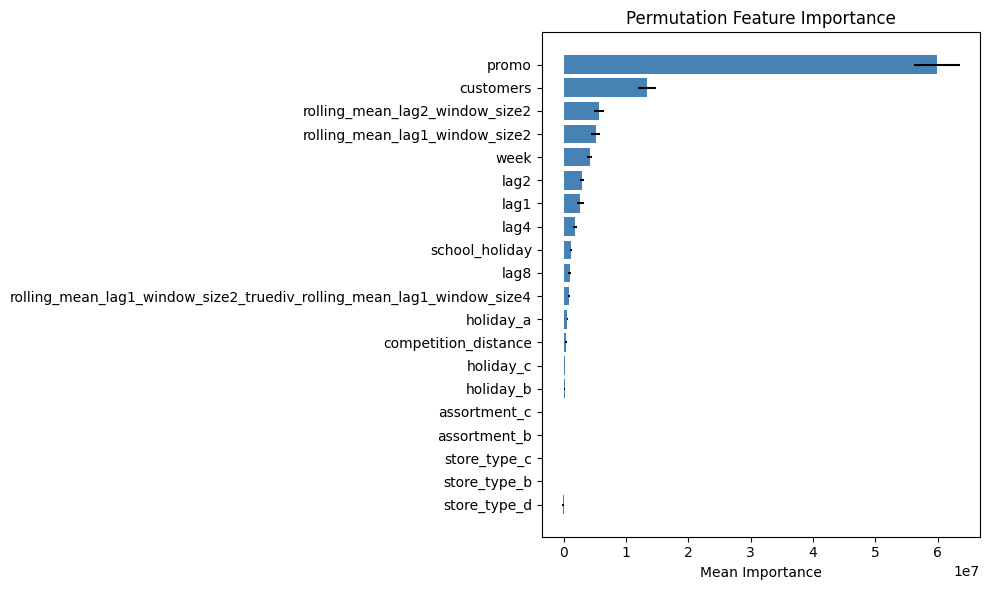

In [97]:
# Create result and plot
sorted_idx = perm_importance.importances_mean.argsort()[::-1]
features = np.array(X.columns)[sorted_idx]
importances = perm_importance.importances_mean[sorted_idx]
std = perm_importance.importances_std[sorted_idx]
plt.figure(figsize=(10, 6))
plt.barh(features, importances, xerr=std, align='center', color='steelblue')
plt.xlabel('Mean Importance')
plt.title('Permutation Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [100]:
from mlforecast.lag_transforms import RollingMean
from mlforecast.feature_engineering import transform_exog
# Filter for first 100 stores
first_100_stores = [f"store_{i}" for i in range(1, 101)]
filtered_data = weekly_sales[weekly_sales['unique_id'].isin(first_100_stores)].copy()

# Create target_series with only unique_id, y, ds columns
target_series = filtered_data[['unique_id', 'y', 'ds']].copy()

# Create transformed_exogv with all other columns (exclude 'y' and 'ds')
exogv = filtered_data.drop(columns=['y']).copy()


transformed_exogv = transform_exog(
    exogv,
    lags=[1],
    lag_transforms={1: [RollingMean(window_size=2)]}  # <- wrapped in a list
)

target_and_exogv = target_series.merge(transformed_exogv, on=['unique_id', 'ds'])

In [103]:
# Speciy model
models = [RandomForestRegressor(n_estimators=500, max_features='sqrt', min_samples_leaf=5)]
fcst = MLForecast(
    models=models,
    freq='W',
    lags=[1, 2],
    date_features= ['week'],
    target_transforms=[Differences([1])],
    lag_transforms={
        1: [RollingMean(window_size=2),
            Combine(
                RollingMean(window_size=2),
                RollingMean(window_size=4),
                operator.truediv)
            ],
        2: [RollingMean(window_size=2)]
    }
)

In [104]:
fcst.fit(target_and_exogv,static_features=[])
fcst.predict(h = 8, X_df=transformed_exogv)

ValueError: Found missing inputs in X_df. It should have one row per id and time for the complete forecasting horizon.
You can get the expected structure by running `MLForecast.make_future_dataframe(h)` or get the missing combinatins in your current `X_df` by running `MLForecast.get_missing_future(h, X_df)`.